Sélection d'actifs liquide et avec peu de frais (possibilité d'y accéder via ETF) dans l'objectif d'être déstiné au retail.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Sélection des actifs basés sur le livre "Les Hedge Funds"

Actions (Moteurs de performance) :

**S&P 500 (Ticker: ^GSPC)** : L'indice de référence mondial. Tendance haussière historique forte.

**Nasdaq 100 (Ticker: ^IXIC)** : Pour capter la "Tech" et la volatilité.

**CAC 40 (Ticker: ^FCHI)** : Puisque vous êtes en France, utile pour comparer.

Valeurs Refuges & Taux (Défensif/Diversification) :

**Or (Ticker: GLD)** : Actif qui trend bien en période d'incertitude (inflation, crise).

**Obligations US 20 ans (Ticker: TLT)** : Souvent décorrélé des actions (quand les actions chutent, les obligations montent souvent).

Matières Premières (Cycles économiques) :

**Pétrole (Ticker: USO ou Futures)**: Très sensible aux tendances macro, mais attention à la volatilité.

Crypto (Optionnel - Pure Momentum) :

**Bitcoin (Ticker: BTC-USD)** : L'actif "retail" par excellence pour le suivi de tendance car il a beaucoup d'inertie (les hausses durent longtemps, les baisses aussi).

Actifs avec des tendances importante ce qui est intéréssant pour notre stratégie directonnelle.

In [2]:
# 1. Définition de votre Univers "Candidat"
# Indices, Or, Pétrole, Taux, Bitcoin, Euro/Dollar
tickers = ['^GSPC', '^IXIC', '^FCHI', 'GLD', 'USO', 'TLT', 'BTC-USD', 'EURUSD=X']
noms = ['Bitcoin', 'EUR/USD', 'Or', 'Bonds 20Y', 'Pétrole', 'CAC40', 'S&P500', 'Nasdaq']

# 2. Téléchargement des données (5 dernières années, bougies hebdomadaires)
print("Téléchargement des données...")
data = yf.download(tickers, period="5y", interval="1wk")['Close']

Téléchargement des données...


/tmp/ipython-input-912162834.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="5y", interval="1wk")['Close']
[*********************100%***********************]  8 of 8 completed


In [3]:
# Renommer les colonnes pour la lisibilité
data.columns = noms
data.head()

,Bitcoin,EUR/USD,Or,Bonds 20Y,Pétrole,CAC40,S&P500,Nasdaq
Date,,,,,,,,
2020-12-21,26272.294922,1.228500,NaN,NaN,NaN,5522.009766,NaN,NaN
2020-12-28,32782.023438,1.214000,178.360001,134.876205,33.009998,5551.410156,3756.070068,12888.280273
2021-01-04,38356.441406,1.223001,173.339996,129.394928,35.430000,5706.879883,3824.679932,13201.980469
2021-01-11,35791.277344,1.208100,171.130005,129.822433,35.340000,5611.689941,3768.250000,12998.500000
2021-01-18,32289.378906,1.217600,173.899994,129.873795,35.230000,5559.569824,3841.469971,13543.059570


In [4]:
data.isna().sum()

,0
Bitcoin,0
EUR/USD,0
Or,1
Bonds 20Y,1
Pétrole,1
CAC40,0
S&P500,1
Nasdaq,1


In [5]:
# 3. Calcul des rendements (pour voir les variations, pas juste le prix)
returns = data.pct_change().dropna()
returns.head()

,Bitcoin,EUR/USD,Or,Bonds 20Y,Pétrole,CAC40,S&P500,Nasdaq
Date,,,,,,,,
2021-01-04,0.170045,0.007414,-0.028145,-0.040639,0.073311,0.028005,0.018266,0.024340
2021-01-11,-0.066877,-0.012184,-0.012749,0.003304,-0.002540,-0.016680,-0.014754,-0.015413
2021-01-18,-0.097842,0.007863,0.016186,0.000396,-0.003113,-0.009288,0.019431,0.041894
2021-01-25,0.025550,-0.003038,-0.007418,0.000790,-0.001419,-0.028844,-0.033120,-0.034879
2021-02-01,0.174821,-0.007373,-0.016222,-0.026118,0.085560,0.048164,0.046467,0.060105


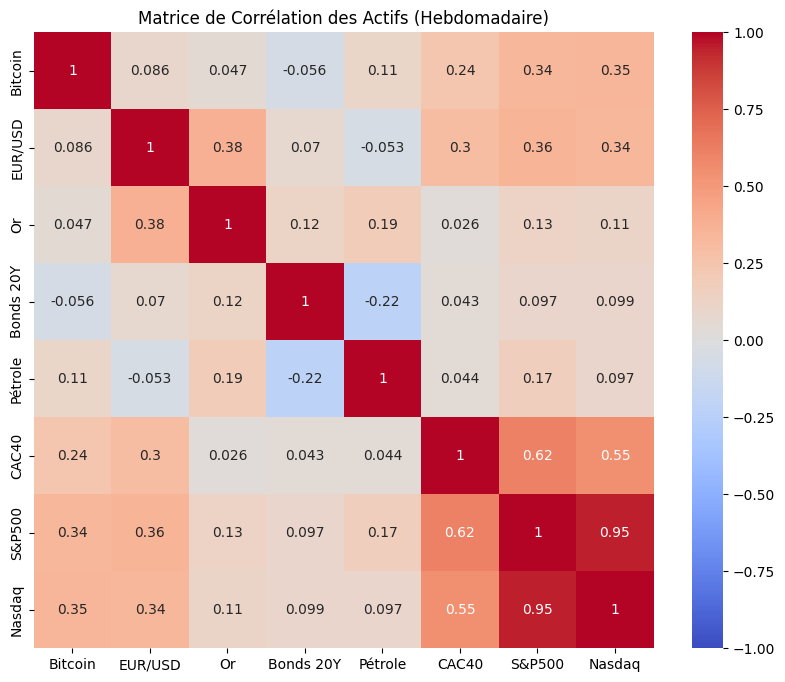

In [6]:
# 4. Analyse de Corrélation (Heatmap)
plt.figure(figsize=(10, 8))
correlation_matrix = returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de Corrélation des Actifs (Hebdomadaire)")
plt.show()

S&P et Nasdaq très fortement corrélé: 0.95
-> On enlève le Nasdaq
Corrélation quasi-nulle ou négative avec le marché (S&P et cac40) pour Bonds 20Y et pétrol et or.

In [7]:
data = data.drop(columns=['Nasdaq'])
returns = returns.drop(columns=['Nasdaq'])

In [8]:
# 5. Analyse Volatilité vs Rendement (Risque/Reward)
summary = pd.DataFrame()
summary['Rendement Annuel Moyen'] = returns.mean() * 52 # 52 semaines
summary['Volatilité (Risque)'] = returns.std() * (52**0.5)

print("\nProfil Risque/Rendement de votre univers :")
print(summary.sort_values(by='Rendement Annuel Moyen', ascending=False))


Profil Risque/Rendement de votre univers :
           Rendement Annuel Moyen  Volatilité (Risque)
Bitcoin                  0.356384             0.565909
Pétrole                  0.197759             0.323142
Or                       0.180545             0.145767
S&P500                   0.135745             0.162164
CAC40                    0.088356             0.158649
EUR/USD                 -0.003422             0.073004
Bonds 20Y               -0.075104             0.147195


Affichage de d'évolution des prix et des courbes d'évolution du rendement

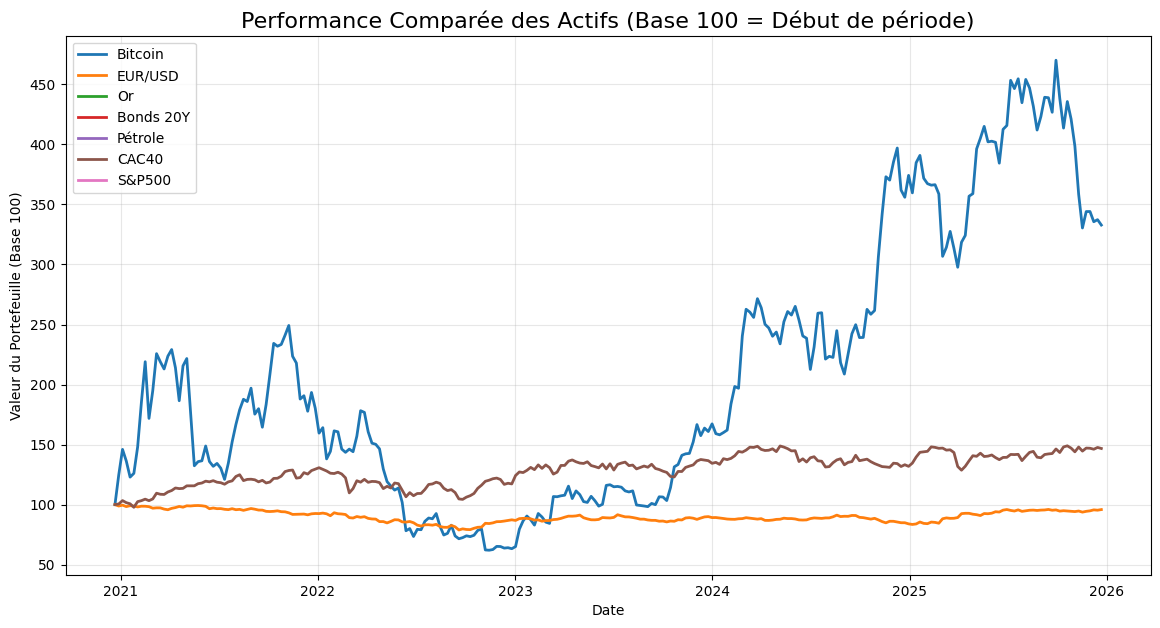

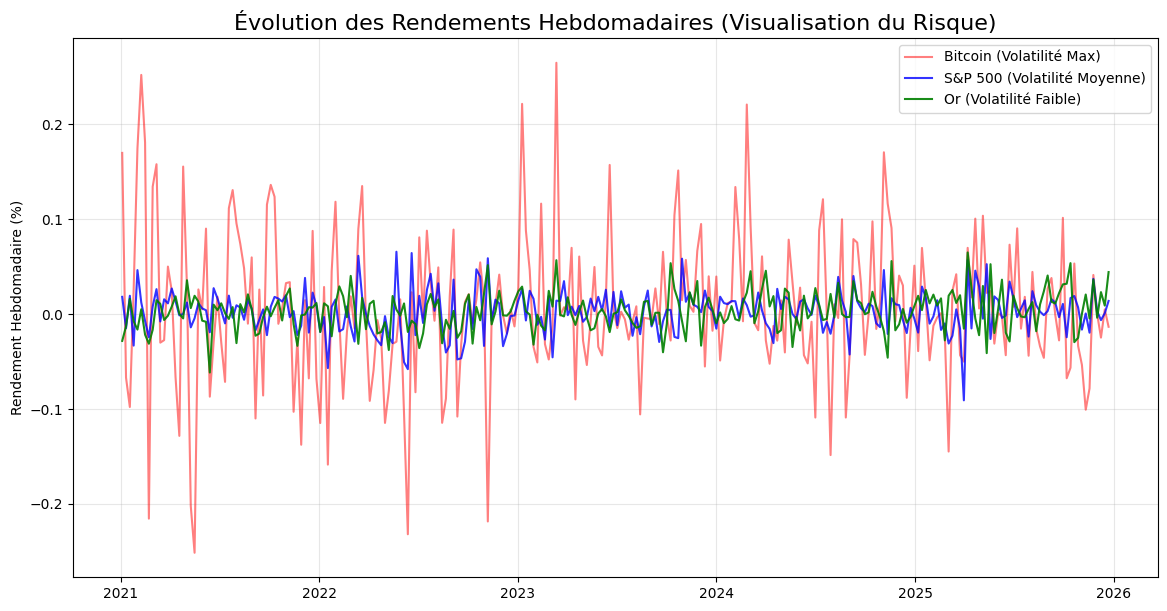

Volatilité Hebdomadaire (Écart-type) :
Bitcoin      0.078477
Pétrole      0.044812
S&P500       0.022488
CAC40        0.022001
Bonds 20Y    0.020412
Or           0.020214
EUR/USD      0.010124
dtype: float64


In [9]:
# ==========================================
# GRAPHIQUE 1 : Évolution des Prix (Base 100)
# ==========================================

# On divise chaque ligne par la première ligne (le prix de départ) et on multiplie par 100
data_base100 = (data / data.iloc[0]) * 100

plt.figure(figsize=(14, 7))
for col in data_base100.columns:
    plt.plot(data_base100.index, data_base100[col], label=col, linewidth=2)

plt.title('Performance Comparée des Actifs (Base 100 = Début de période)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Valeur du Portefeuille (Base 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# GRAPHIQUE 2 : Évolution des Rendements (Volatilité)
# ==========================================

plt.figure(figsize=(14, 7))
# On trace juste 3 actifs représentatifs pour ne pas surcharger le graph
# Actions (SPY), Valeur Refuge (Or), et Actif Volatil (Bitcoin)
plt.plot(returns.index, returns['Bitcoin'], label='Bitcoin (Volatilité Max)', alpha=0.5, color='red')
plt.plot(returns.index, returns['S&P500'], label='S&P 500 (Volatilité Moyenne)', alpha=0.8, color='blue')
plt.plot(returns.index, returns['Or'], label='Or (Volatilité Faible)', alpha=0.9, color='green')

plt.title('Évolution des Rendements Hebdomadaires (Visualisation du Risque)', fontsize=16)
plt.ylabel('Rendement Hebdomadaire (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Petit tableau statistique pour chiffrer ce qu'on voit
print("Volatilité Hebdomadaire (Écart-type) :")
print(returns.std().sort_values(ascending=False))

Implémentation du cours de Dauphine et des principes de Markowitz à notre projet

Avant d'optimiser, Markowitz dit qu'un portefeuille est défini par deux choses : son espérance de rendement ($E$) et son risque ($\sigma^2$).

*   Etape 1: Création de la matrice de variance covariance $Σ$
*   Etape 2: Calculer la volatilité du portefeuille: $\sigma_p = \sqrt{w^T \Sigma w}$ (où $w$ est le vecteur des poids).


In [10]:
# 1. Fonction objectif : Minimiser la Variance (w.T * Sigma * w)
# Formule de la variance du portefeuille

# ---------------------------------------------------------
# 1. Fonctions "Atomiques" (Extérieures et Testables)
# ---------------------------------------------------------

def portfolio_variance(weights, cov_matrix):
    """
    Calcule la variance du portefeuille : w.T * Sigma * w

    Args:
        weights (np.array): Le vecteur des poids (w)
        cov_matrix (np.array): La matrice de variance-covariance (Sigma)
    """
    return weights.T @ cov_matrix @ weights

def portfolio_return(weights, expected_returns):
    """
    Calcule le rendement espéré : w.T * mu
    """
    return weights.T @ expected_returns

In [11]:
import numpy as np

# test avec portefeuille équipondéré
n_assets = len(returns.columns)
cov_matrix = returns.cov()
init_guess = np.array([1/n_assets] * n_assets)
#print(init_guess)
rendement = portfolio_return(init_guess, returns.mean())
variance = portfolio_variance(init_guess, cov_matrix)

print("Rendement : ", rendement)
print("Variance : ", variance)

Rendement :  0.002418306368674272
Variance :  0.0003009232423751283


Partie optimisation des poids pour minimiser la variance avec un rendement fixé:

Le Problème Mathématique :On cherche le vecteur de poids $w$ qui :

1.   Minimise la variance : $\frac{1}{2} w^T \Sigma w$
2.   Sous contrainte de budget : $\sum w_i = 1$ (ou $w^T \mathbf{1} = 1$)
3. Sous contrainte de rendement cible : $w^T \mu = r_{target}$

La Résolution (Méthode Dauphine vs Python) :Dans le cours de Dauphine, la solution analytique utilise l'inversion de matrice ($\Sigma^{-1}$) et les constantes $A, B, C$.

$$w^* = \lambda_1 (\Sigma^{-1} \mathbf{1}) + \lambda_2 (\Sigma^{-1} \mu)$$

Implémentation Python (Scipy): Plutôt que d'inverser des matrices manuellement (instable numériquement), on utilise un "Solver".

Démonstration du problème d'optimisation:

1. Le Problème d'Optimisation

On cherche le vecteur de poids $w$ (de taille $N \times 1$) qui minimise la variance du portefeuille sous deux contraintes :

Budget : La somme des poids vaut 1 ($w^T \mathbf{1} = 1$).

Rendement : Le rendement espéré du portefeuille doit être égal à une cible $r^*$ ($w^T \mu = r^*$).

Le programme s'écrit :$$\begin{cases}
\min_w \frac{1}{2} w^T \Sigma w \\
\text{s.c. } w^T \mathbf{1} = 1 \\
\text{s.c. } w^T \mu = r^*
\end{cases}$$

2. Le Lagrangien et les $\lambda$

Pour résoudre ce problème sous contrainte, on construit le Lagrangien $\mathcal{L}$. On introduit deux variables artificielles, $\lambda_1$ et $\lambda_2$, appelées Multiplicateurs de Lagrange.$$\mathcal{L}(w, \lambda_1, \lambda_2) = \frac{1}{2} w^T \Sigma w - \lambda_1 (w^T \mathbf{1} - 1) - \lambda_2 (w^T \mu - r^*)$$

À quoi correspondent $\lambda_1$ et $\lambda_2$ ?

Économiquement, ce sont des "prix fictifs" (shadow prices). Ils mesurent combien la variance minimale changerait si on relaxait la contrainte d'une unité.$\lambda_1$ est lié à la contrainte de budget.$\lambda_2$ est lié à la contrainte de rendement (c'est le coût en risque pour obtenir un point de rendement supplémentaire).

3. La Démonstration (Conditions du Premier Ordre)

On dérive le Lagrangien par rapport à $w$ et on annule la dérivée :$$\frac{\partial \mathcal{L}}{\partial w} = \Sigma w - \lambda_1 \mathbf{1} - \lambda_2 \mu = 0$$Cela nous donne l'expression du vecteur $w$ optimal en fonction des $\lambda$ (en multipliant par l'inverse de la matrice de covariance $\Sigma^{-1}$) :$$\Sigma w = \lambda_1 \mathbf{1} + \lambda_2 \mu$$$$ \boxed{w^* = \lambda_1 (\Sigma^{-1} \mathbf{1}) + \lambda_2 (\Sigma^{-1} \mu)} \quad (*)$$

C'est ici que l'on voit que tout portefeuille efficient est une combinaison linéaire de deux portefeuilles de base (Théorème des deux fonds).

4. Définition des Constantes A, B, C

Pour trouver les valeurs de $\lambda_1$ et $\lambda_2$, on réinjecte l'équation $(*)$ dans nos deux contraintes initiales.

Contrainte 1 (Budget) : $$w^T \mathbf{1} = 1$$
$$(\lambda_1 \mathbf{1}^T \Sigma^{-1} + \lambda_2 \mu^T \Sigma^{-1}) \mathbf{1} = 1$$
$$\lambda_1 (\mathbf{1}^T \Sigma^{-1} \mathbf{1}) + \lambda_2 (\mu^T \Sigma^{-1} \mathbf{1}) = 1$$

Contrainte 2 (Rendement) : $$w^T \mu = r^*$$
$$(\lambda_1 \mathbf{1}^T \Sigma^{-1} + \lambda_2 \mu^T \Sigma^{-1}) \mu = r^*$$
$$\lambda_1 (\mathbf{1}^T \Sigma^{-1} \mu) + \lambda_2 (\mu^T \Sigma^{-1} \mu) = r^*$$

C'est ici qu'on définit les scalaires (les constantes) pour simplifier l'écriture.
Dans la notation classique (Merton/Dauphine) :

$C = \mathbf{1}^T \Sigma^{-1} \mathbf{1}$ (Somme de tous les termes de la matrice inverse).
$A = \mathbf{1}^T \Sigma^{-1} \mu = \mu^T \Sigma^{-1} \mathbf{1}$ (Produit croisé rendement/risque).
$B = \mu^T \Sigma^{-1} \mu$ (Produit quadratique des rendements pondérés par le risque).

Le système d'équations devient alors un simple système linéaire 2x2 :$$\begin{cases}
C \lambda_1 + A \lambda_2 = 1 \\
A \lambda_1 + B \lambda_2 = r^*
\end{cases}$$

5. Résolution et Résultat FinalOn résout ce système pour trouver $\lambda_1$ et $\lambda_2$.

On calcule le déterminant $D$ :$$D = BC - A^2$$

Par la règle de Cramer (ou substitution), on trouve :

$$\lambda_1 = \frac{B - A r^*}{D} \quad \text{et} \quad \lambda_2 = \frac{C r^* - A}{D}$$

Enfin, on remplace ces valeurs de $\lambda$ dans l'équation $(*)$ pour obtenir la formule finale du portefeuille optimal pour un rendement cible $r^*$ :

$$\boxed{w^* = \frac{B - A r^*}{D} (\Sigma^{-1} \mathbf{1}) + \frac{C r^* - A}{D} (\Sigma^{-1} \mu)}$$

In [12]:
from scipy.optimize import minimize # Pour faire la minimisation

# ---------------------------------------------------------
# 2. La Fonction d'Optimisation (Le Chef d'Orchestre)
# ---------------------------------------------------------

def optimize_portfolio(expected_returns, cov_matrix, target_return):
    """
    Trouve les poids optimaux pour minimiser la volatilité
    donné un rendement cible.
    """
    n_assets = len(expected_returns)

    # --- Définition des Contraintes ---

    # Contrainte 1 : Budget (Somme des poids = 1)
    # On peut utiliser une lambda ou une fonction externe aussi
    cons_budget = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    # Contrainte 2 : Rendement Cible (Rendement portefeuille = target)
    # Notez qu'on passe aussi 'expected_returns' via args si on sortait cette fonction
    cons_return = {'type': 'eq',
                   'fun': lambda w: portfolio_return(w, expected_returns) - target_return}

    constraints = (cons_budget, cons_return)

    # --- Bornes (-1 à 1 pour chaque actif, on autorise la vente à découvert) ---
    bounds = tuple((-1, 1) for _ in range(n_assets))

    # --- Point de départ (Equi-pondéré) ---
    init_guess = np.array([1/n_assets] * n_assets)

    # --- LANCEMENT DE L'OPTIMISATION ---
    # C'est ici que la magie opère avec 'args'
    result = minimize(
        fun=portfolio_variance,      # La fonction à minimiser (externe)
        x0=init_guess,               # Point de départ
        args=(cov_matrix,),          # <--- IMPORTANT : On passe la matrice ici !
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        print("Attention : L'optimisation a échoué !")

    return result.x

In [13]:
# C. Calcul des Inputs Statistiques (Annualisés)
# On multiplie par 52 car il y a 52 semaines dans une année.
# Si vous étiez en journalier, on multiplierait par 252.

mu = returns.mean() * 52           # Rendements Espérés (Annualisés)
sigma = returns.cov() * 52         # Matrice de Covariance (Annualisée)

print("Rendements espérés (historiques) :\n", mu)
print("-" * 30)

Rendements espérés (historiques) :
 Bitcoin      0.356384
EUR/USD     -0.003422
Or           0.180545
Bonds 20Y   -0.075104
Pétrole      0.197759
CAC40        0.088356
S&P500       0.135745
dtype: float64
------------------------------


In [14]:

optimal_weight = optimize_portfolio(expected_returns=mu, cov_matrix=sigma, target_return=0.15)

optimal_rendement = portfolio_return(optimal_weight, mu)
optimal_variance = portfolio_variance(optimal_weight, sigma)

print("Rendement Optimal :", optimal_rendement)
print("Variance Optimal :", optimal_variance)


Rendement Optimal : 0.14999999999935232
Variance Optimal : 0.010903622974647443


Sécurité en cas de crise ou de volatilité extrêmement élevée:

Passage au portefeuille de variance minimale, les poids sont déterminés de la manière suivante:

Formule analytique (Cours) : $w_{min} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^T \Sigma^{-1} \mathbf{1}}$

In [15]:
def global_ptf_min_var(cov_matrix):
    """
    Calcule les poids du Portefeuille de Variance Minimale (Global Minimum Variance).
    Formule analytique : w = (Sigma^-1 * 1) / (1^T * Sigma^-1 * 1)
    """
    # Inverse de la matrice de covariance (Sigma^-1)
    # Note: On ajoute une petite valeur sur la diagonale (jitter) si la matrice est singulière
    try:
        inv_cov = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        # Fallback de sécurité si la matrice n'est pas inversible
        return np.ones(len(cov_matrix)) / len(cov_matrix)

    # Vecteur de 1 (taille N)
    ones = np.ones(len(cov_matrix))

    # Numérateur : Sigma^-1 * 1
    # On fait un produit matriciel (dot product)
    numerator = inv_cov @ ones

    # Dénominateur : 1^T * (Sigma^-1 * 1)
    # C'est la somme des éléments du numérateur
    denominator = ones.T @ numerator

    # Calcul final des poids
    weights = numerator / denominator

    return weights

In [16]:
global_ptf_min_var(cov_matrix=sigma)

array([ 0.00318995,  0.71421103,  0.00229885,  0.19200276,  0.06799724,
        0.07715419, -0.05685402])